In [1]:
import pandas as pd
from pathlib import Path

In [2]:
DATA_PATH = Path("../data/processed/higher_education_clean.csv")

df = pd.read_csv(DATA_PATH)

In [3]:
df.head()

,ANIO,TIPO_UNIV,NIVEL_ACADEM,OF_ACADEM,DISCIP_OCDE,DISCIP_ESPECIF,TIPO_ALUMNO,VALOR
0,2014,Privado,Grado,Otros,Ciencias Agrícolas,Ciencias Agropecuarias,EGRESADOS,124
1,2014,Privado,Grado,Otros,Ciencias Agrícolas,Ciencias Agropecuarias,ESTUDIANTES,1475
2,2014,Privado,Grado,Otros,Ciencias Agrícolas,Veterinaria,EGRESADOS,119
3,2014,Privado,Grado,Otros,Ciencias Agrícolas,Veterinaria,ESTUDIANTES,2134
4,2014,Privado,Posgrado,Doctorado,Ciencias Agrícolas,Ciencias Agropecuarias,EGRESADOS,2


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6074 entries, 0 to 6073
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ANIO            6074 non-null   int64
 1   TIPO_UNIV       6074 non-null   str  
 2   NIVEL_ACADEM    6074 non-null   str  
 3   OF_ACADEM       6074 non-null   str  
 4   DISCIP_OCDE     6074 non-null   str  
 5   DISCIP_ESPECIF  6074 non-null   str  
 6   TIPO_ALUMNO     6074 non-null   str  
 7   VALOR           6074 non-null   int64
dtypes: int64(2), str(6)
memory usage: 379.8 KB


In [5]:
students_df = df[
    df["TIPO_ALUMNO"] == "ESTUDIANTES"
]

In [6]:
students_by_year = (
    students_df
    .groupby("ANIO")["VALOR"]
    .sum()
    .reset_index()
)

students_by_year

,ANIO,VALOR
0,2014,2005469
1,2015,2053651
2,2016,1930057
3,2017,1985699
4,2018,2045502
5,2019,2145062
6,2020,2459687
7,2021,2516174
8,2022,2703679
9,2023,2730800


In [7]:
students_by_year["VARIACION_%"] = (
    students_by_year["VALOR"]
    .pct_change()
    .mul(100)
    .round(2)
)

students_by_year

,ANIO,VALOR,VARIACION_%
0,2014,2005469,NaN
1,2015,2053651,2.40
2,2016,1930057,-6.02
3,2017,1985699,2.88
4,2018,2045502,3.01
5,2019,2145062,4.87
6,2020,2459687,14.67
7,2021,2516174,2.30
8,2022,2703679,7.45
9,2023,2730800,1.00


<Axes: xlabel='ANIO'>

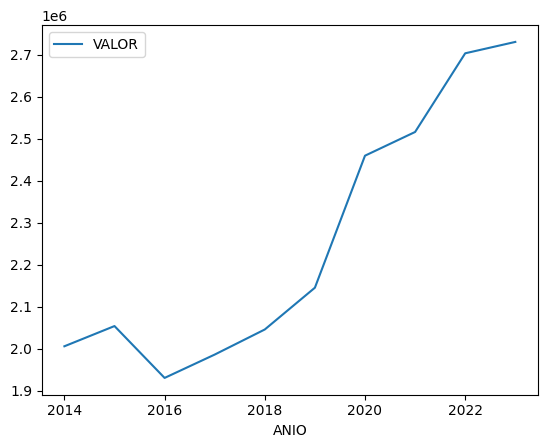

In [8]:
students_by_year.plot(
    x="ANIO",
    y="VALOR",
    kind="line"
)

# KPI 1 - Evolución de estudiantes

## Hallazgos

- La matrícula universitaria creció de 2,0 millones a 2,7 millones de estudiantes entre el período 2013 - 2023
- El crecimiento fue de aproximadamente 725 mil estudiantes
- El mayor incremento interanual se registró en 2020 (+14,67%)
- El único descenso relevante ocurrió en 2016 (-6,02%)
- La tendencia general del período es claramente creciente, inclusive post pandemia donde se esperaba valores menores

In [9]:
students_public_private = (
    students_df
    .groupby(
        ["ANIO", "TIPO_UNIV"]
    )["VALOR"]
    .sum()
    .reset_index()
)

students_public_private

,ANIO,TIPO_UNIV,VALOR
0,2014,Privado,435357
1,2014,Pública,1570112
2,2015,Privado,444494
3,2015,Pública,1609157
4,2016,Privado,433700
5,2016,Pública,1496357
6,2017,Privado,431604
7,2017,Pública,1554095
8,2018,Privado,449203
9,2018,Pública,1596299


<Axes: xlabel='ANIO'>

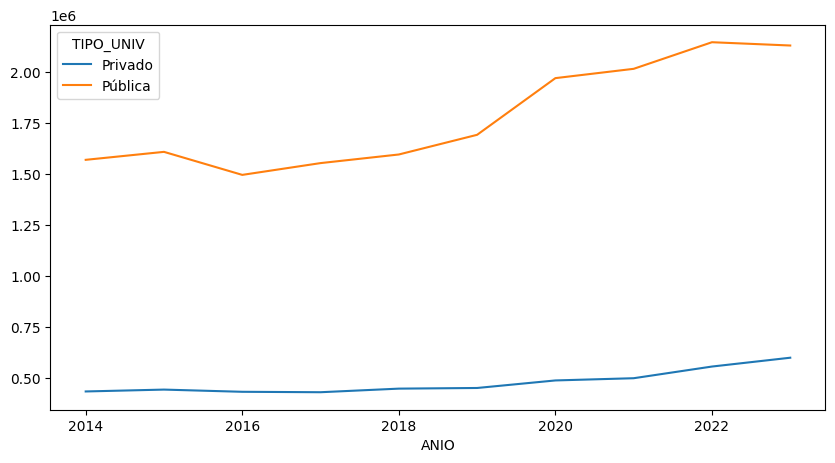

In [10]:
students_public_private.pivot(
    index="ANIO",
    columns="TIPO_UNIV",
    values="VALOR"
).plot(figsize=(10,5))

# KPI 2 - Estudiantes por tipo de universidad

## Hallazgos

- El sistema argentino es predominantemente público 
- Aproximadamente 8 de cada 10 estudiantes universitarios argentinos estudian en instituciones públicas
- Ambas crecieron, las universidades públicas +560.048 estudiantes y las privadas +165.283 estudiantes
- Más de tres cuartas partes del crecimiento del sistema universitario argentino entre 2014 y 2023 fueron absorbidas por universidades públicas
- El salto de 2020 (pandemia) fue mucho más fuerte en universidades públicas que privadas

In [11]:
graduates_df = df[
    df["TIPO_ALUMNO"] == "EGRESADOS"
]

In [12]:
graduates_by_year = (
    graduates_df
    .groupby("ANIO")["VALOR"]
    .sum()
    .reset_index()
)

graduates_by_year

,ANIO,VALOR
0,2014,134234
1,2015,139871
2,2016,119794
3,2017,118983
4,2018,126933
5,2019,125560
6,2020,134488
7,2021,135465
8,2022,162168
9,2023,159730


In [13]:
graduates_by_year["VARIACION_%"] = (
    graduates_by_year["VALOR"]
    .pct_change()
    .mul(100)
    .round(2)
)

graduates_by_year

,ANIO,VALOR,VARIACION_%
0,2014,134234,NaN
1,2015,139871,4.20
2,2016,119794,-14.35
3,2017,118983,-0.68
4,2018,126933,6.68
5,2019,125560,-1.08
6,2020,134488,7.11
7,2021,135465,0.73
8,2022,162168,19.71
9,2023,159730,-1.50


<Axes: title={'center': 'Evolución de egresados'}, xlabel='ANIO'>

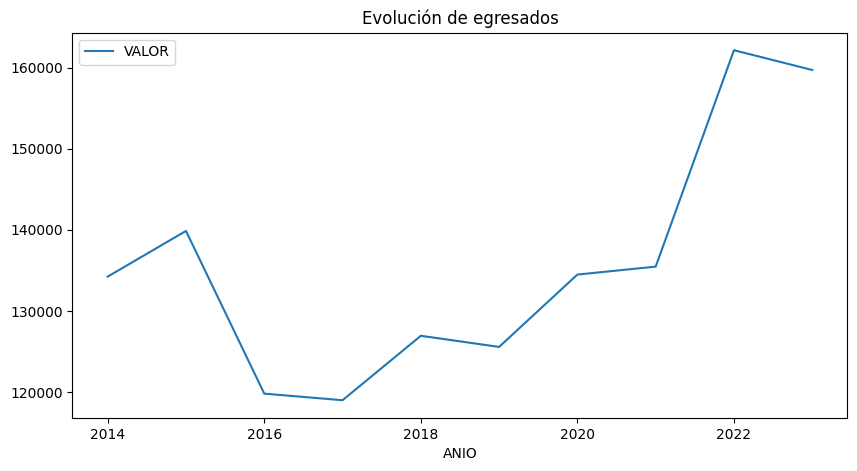

In [14]:
graduates_by_year.plot(
    x="ANIO",
    y="VALOR",
    kind="line",
    figsize=(10, 5),
    title="Evolución de egresados"
)

In [15]:
comparison_df = (
    students_by_year
    .merge(
        graduates_by_year,
        on="ANIO",
        suffixes=("_ESTUDIANTES", "_EGRESADOS")
    )
)

comparison_df

,ANIO,VALOR_ESTUDIANTES,VARIACION_%_ESTUDIANTES,VALOR_EGRESADOS,VARIACION_%_EGRESADOS
0,2014,2005469,NaN,134234,NaN
1,2015,2053651,2.40,139871,4.20
2,2016,1930057,-6.02,119794,-14.35
3,2017,1985699,2.88,118983,-0.68
4,2018,2045502,3.01,126933,6.68
5,2019,2145062,4.87,125560,-1.08
6,2020,2459687,14.67,134488,7.11
7,2021,2516174,2.30,135465,0.73
8,2022,2703679,7.45,162168,19.71
9,2023,2730800,1.00,159730,-1.50


In [16]:
comparison_df["TASA_EGRESO_%"] = (
    comparison_df["VALOR_EGRESADOS"]
    / comparison_df["VALOR_ESTUDIANTES"]
    * 100
).round(2)

comparison_df

,ANIO,VALOR_ESTUDIANTES,VARIACION_%_ESTUDIANTES,VALOR_EGRESADOS,VARIACION_%_EGRESADOS,TASA_EGRESO_%
0,2014,2005469,NaN,134234,NaN,6.69
1,2015,2053651,2.40,139871,4.20,6.81
2,2016,1930057,-6.02,119794,-14.35,6.21
3,2017,1985699,2.88,118983,-0.68,5.99
4,2018,2045502,3.01,126933,6.68,6.21
5,2019,2145062,4.87,125560,-1.08,5.85
6,2020,2459687,14.67,134488,7.11,5.47
7,2021,2516174,2.30,135465,0.73,5.38
8,2022,2703679,7.45,162168,19.71,6.00
9,2023,2730800,1.00,159730,-1.50,5.85


# KPI 3 - Evolución de egresados

## Hallazgos

- Los egresados crecieron de 134.234 a 159.730 entre el período 2014 - 2023
- El crecimiento acumulado fue del 19%
- El crecimiento de egresados fue menor al crecimiento de estudiantes (36%)
- La tasa de egreso descendió de 6,69% a 5,85%
- El mayor crecimiento de egresados ocurrió en 2022 (+19,71%)
- Durante la pandemia la matrícula creció más rápido que la cantidad de graduados

In [17]:
graduates_public_private = (
    graduates_df
    .groupby(
        ["ANIO", "TIPO_UNIV"]
    )["VALOR"]
    .sum()
    .reset_index()
)

graduates_public_private

,ANIO,TIPO_UNIV,VALOR
0,2014,Privado,44031
1,2014,Pública,90203
2,2015,Privado,47200
3,2015,Pública,92671
4,2016,Privado,42442
5,2016,Pública,77352
6,2017,Privado,40101
7,2017,Pública,78882
8,2018,Privado,48355
9,2018,Pública,78578


In [18]:
graduates_pivot = (
    graduates_public_private
    .pivot(
        index="ANIO",
        columns="TIPO_UNIV",
        values="VALOR"
    )
)

graduates_pivot

TIPO_UNIV,Privado,Pública
ANIO,,
2014,44031,90203
2015,47200,92671
2016,42442,77352
2017,40101,78882
2018,48355,78578
2019,49853,75707
2020,55413,79075
2021,52194,83271
2022,53791,108377


<Axes: title={'center': 'Evolución de egresados por tipo de universidad'}, xlabel='ANIO'>

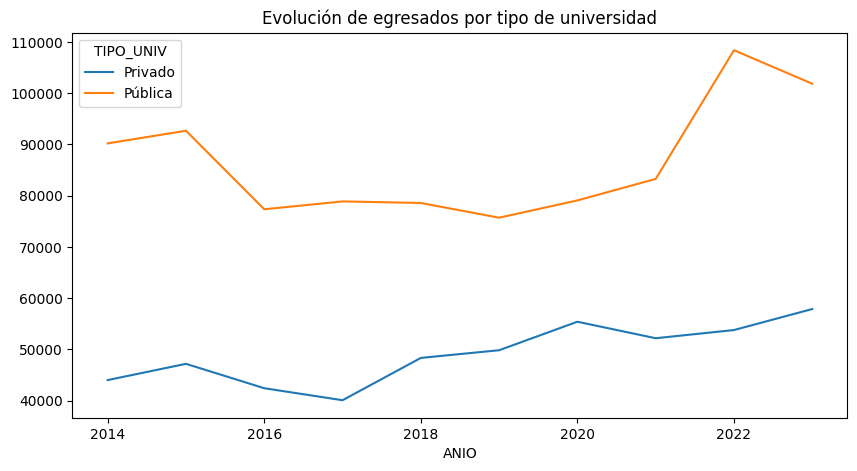

In [19]:
graduates_pivot.plot(
    figsize=(10,5),
    title="Evolución de egresados por tipo de universidad"
)

In [20]:
students_by_type = (
    students_df
    .groupby("TIPO_UNIV")["VALOR"]
    .sum()
)

In [21]:
graduates_by_type = (
    graduates_df
    .groupby("TIPO_UNIV")["VALOR"]
    .sum()
)

In [22]:
graduation_rate = (
    graduates_by_type
    / students_by_type
    * 100
).round(2)

graduation_rate

TIPO_UNIV
Privado    10.25
Pública     4.87
Name: VALOR, dtype: float64

In [23]:
students_by_discipline = (
    students_df
    .groupby("DISCIP_OCDE")["VALOR"]
    .sum()
    .reset_index()
    .sort_values(
        by="VALOR",
        ascending=False
    )
)

students_by_discipline

,DISCIP_OCDE,VALOR
2,Ciencias Sociales,10978654
1,Ciencias Médicas,4018746
3,Exactas y Naturales,2558858
5,Ingeniería y Tecnología,2496454
4,Humanidades,1871592
0,Ciencias Agrícolas,651476


In [24]:
students_by_discipline["PARTICIPACION_%"] = (
    students_by_discipline["VALOR"]
    / students_by_discipline["VALOR"].sum()
    * 100
).round(2)

students_by_discipline

,DISCIP_OCDE,VALOR,PARTICIPACION_%
2,Ciencias Sociales,10978654,48.63
1,Ciencias Médicas,4018746,17.80
3,Exactas y Naturales,2558858,11.33
5,Ingeniería y Tecnología,2496454,11.06
4,Humanidades,1871592,8.29
0,Ciencias Agrícolas,651476,2.89


<Axes: title={'center': 'Estudiantes por disciplina'}, xlabel='DISCIP_OCDE'>

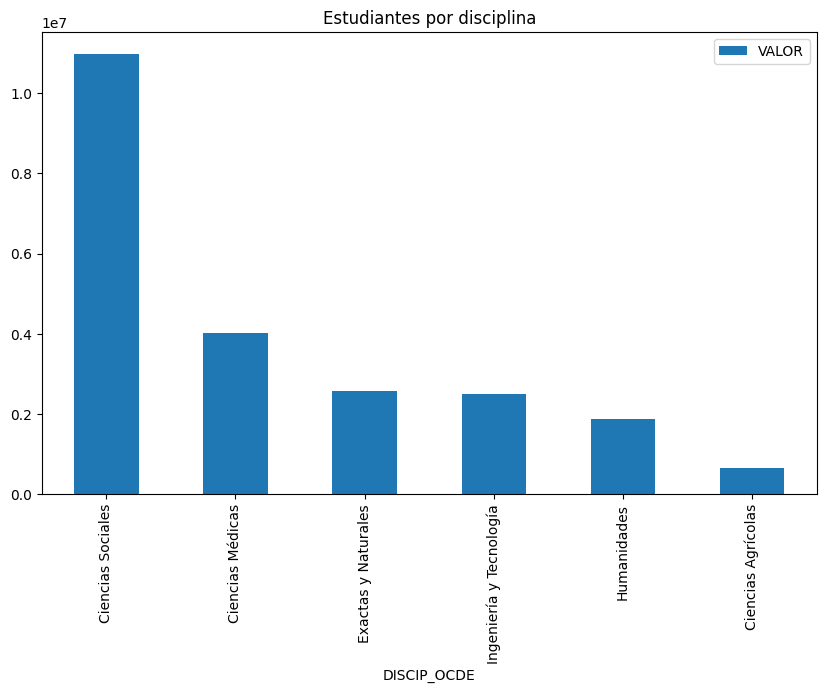

In [25]:
students_by_discipline.plot(
    kind="bar",
    x="DISCIP_OCDE",
    y="VALOR",
    figsize=(10, 6),
    title="Estudiantes por disciplina"
)

In [26]:
graduates_by_discipline = (
    graduates_df
    .groupby("DISCIP_OCDE")["VALOR"]
    .sum()
    .reset_index()
    .sort_values(
        by="VALOR",
        ascending=False
    )
)

graduates_by_discipline

,DISCIP_OCDE,VALOR
2,Ciencias Sociales,738234
1,Ciencias Médicas,251734
5,Ingeniería y Tecnología,134824
3,Exactas y Naturales,122237
4,Humanidades,78940
0,Ciencias Agrícolas,31257


In [27]:
graduates_by_discipline["PARTICIPACION_%"] = (
    graduates_by_discipline["VALOR"]
    / graduates_by_discipline["VALOR"].sum()
    * 100
).round(2)

graduates_by_discipline

,DISCIP_OCDE,VALOR,PARTICIPACION_%
2,Ciencias Sociales,738234,54.39
1,Ciencias Médicas,251734,18.55
5,Ingeniería y Tecnología,134824,9.93
3,Exactas y Naturales,122237,9.01
4,Humanidades,78940,5.82
0,Ciencias Agrícolas,31257,2.30


In [28]:
informatics_df = df[
    df["DISCIP_ESPECIF"] == "Informática"
]

informatics_df.head()

,ANIO,TIPO_UNIV,NIVEL_ACADEM,OF_ACADEM,DISCIP_OCDE,DISCIP_ESPECIF,TIPO_ALUMNO,VALOR
3244,2014,Privado,Grado,Otros,Exactas y Naturales,Informática,EGRESADOS,758
3245,2014,Privado,Grado,Otros,Exactas y Naturales,Informática,ESTUDIANTES,11748
3250,2014,Privado,Posgrado,Doctorado,Exactas y Naturales,Informática,EGRESADOS,1
3251,2014,Privado,Posgrado,Doctorado,Exactas y Naturales,Informática,ESTUDIANTES,2
3256,2014,Privado,Posgrado,Especialidad,Exactas y Naturales,Informática,EGRESADOS,4


In [29]:
informatics_df.shape

(252, 8)

In [30]:
informatics_students = informatics_df[
    informatics_df["TIPO_ALUMNO"] == "ESTUDIANTES"
]

In [31]:
informatics_students_by_year = (
    informatics_students
    .groupby("ANIO")["VALOR"]
    .sum()
    .reset_index()
)

informatics_students_by_year

,ANIO,VALOR
0,2014,79916
1,2015,81669
2,2016,76237
3,2017,78992
4,2018,83421
5,2019,89708
6,2020,110052
7,2021,123476
8,2022,150206
9,2023,177525


In [32]:
informatics_students_by_year["VARIACION_%"] = (
    informatics_students_by_year["VALOR"]
    .pct_change()
    .mul(100)
    .round(2)
)

informatics_students_by_year

,ANIO,VALOR,VARIACION_%
0,2014,79916,NaN
1,2015,81669,2.19
2,2016,76237,-6.65
3,2017,78992,3.61
4,2018,83421,5.61
5,2019,89708,7.54
6,2020,110052,22.68
7,2021,123476,12.20
8,2022,150206,21.65
9,2023,177525,18.19


In [33]:
informatics_graduates = informatics_df[
    informatics_df["TIPO_ALUMNO"] == "EGRESADOS"
]

In [34]:
informatics_graduates_by_year = (
    informatics_graduates
    .groupby("ANIO")["VALOR"]
    .sum()
    .reset_index()
)

informatics_graduates_by_year

,ANIO,VALOR
0,2014,3899
1,2015,3927
2,2016,2978
3,2017,2887
4,2018,3254
5,2019,2732
6,2020,2682
7,2021,2837
8,2022,2937
9,2023,3883


In [35]:
informatics_comparison = (
    informatics_students_by_year
    .merge(
        informatics_graduates_by_year,
        on="ANIO",
        suffixes=("_ESTUDIANTES", "_EGRESADOS")
    )
)

informatics_comparison

,ANIO,VALOR_ESTUDIANTES,VARIACION_%,VALOR_EGRESADOS
0,2014,79916,NaN,3899
1,2015,81669,2.19,3927
2,2016,76237,-6.65,2978
3,2017,78992,3.61,2887
4,2018,83421,5.61,3254
5,2019,89708,7.54,2732
6,2020,110052,22.68,2682
7,2021,123476,12.20,2837
8,2022,150206,21.65,2937
9,2023,177525,18.19,3883


In [36]:
informatics_comparison["TASA_EGRESO_%"] = (
    informatics_comparison["VALOR_EGRESADOS"]
    /
    informatics_comparison["VALOR_ESTUDIANTES"]
    * 100
).round(2)

informatics_comparison

,ANIO,VALOR_ESTUDIANTES,VARIACION_%,VALOR_EGRESADOS,TASA_EGRESO_%
0,2014,79916,NaN,3899,4.88
1,2015,81669,2.19,3927,4.81
2,2016,76237,-6.65,2978,3.91
3,2017,78992,3.61,2887,3.65
4,2018,83421,5.61,3254,3.90
5,2019,89708,7.54,2732,3.05
6,2020,110052,22.68,2682,2.44
7,2021,123476,12.20,2837,2.30
8,2022,150206,21.65,2937,1.96
9,2023,177525,18.19,3883,2.19


In [37]:
informatics_by_university = (
    informatics_df
    .groupby(
        ["ANIO", "TIPO_UNIV", "TIPO_ALUMNO"]
    )["VALOR"]
    .sum()
    .reset_index()
)

informatics_by_university

,ANIO,TIPO_UNIV,TIPO_ALUMNO,VALOR
0,2014,Privado,EGRESADOS,1062
1,2014,Privado,ESTUDIANTES,12538
2,2014,Pública,EGRESADOS,2837
3,2014,Pública,ESTUDIANTES,67378
4,2015,Privado,EGRESADOS,1086
5,2015,Privado,ESTUDIANTES,12148
6,2015,Pública,EGRESADOS,2841
7,2015,Pública,ESTUDIANTES,69521
8,2016,Privado,EGRESADOS,703
9,2016,Privado,ESTUDIANTES,11477


In [38]:
students_by_specific_discipline = (
    students_df
    .groupby("DISCIP_ESPECIF")["VALOR"]
    .sum()
    .reset_index()
    .sort_values(
        by="VALOR",
        ascending=False
    )
    .reset_index(drop=True)
)

students_by_specific_discipline.head(10)

,DISCIP_ESPECIF,VALOR
0,Economía y Administración,3776336
1,Derecho,2442001
2,Paramédicas y Auxiliares de la Medicina,2082062
3,Educación,1401851
4,Medicina,1288194
5,Ingeniería,1278529
6,Psicología,1239743
7,Arquitectura y Diseño,1209733
8,Informática,1051202
9,Industrias,791709


In [39]:
students_by_specific_discipline["PARTICIPACION_%"] = (
    students_by_specific_discipline["VALOR"]
    / students_by_specific_discipline["VALOR"].sum()
    * 100
).round(2)

students_by_specific_discipline.head(10)

,DISCIP_ESPECIF,VALOR,PARTICIPACION_%
0,Economía y Administración,3776336,16.73
1,Derecho,2442001,10.82
2,Paramédicas y Auxiliares de la Medicina,2082062,9.22
3,Educación,1401851,6.21
4,Medicina,1288194,5.71
5,Ingeniería,1278529,5.66
6,Psicología,1239743,5.49
7,Arquitectura y Diseño,1209733,5.36
8,Informática,1051202,4.66
9,Industrias,791709,3.51


In [40]:
graduates_by_specific_discipline = (
    graduates_df
    .groupby("DISCIP_ESPECIF")["VALOR"]
    .sum()
    .reset_index()
    .sort_values(
        by="VALOR",
        ascending=False
    )
    .reset_index(drop=True)
)

graduates_by_specific_discipline.head(10)

,DISCIP_ESPECIF,VALOR
0,Economía y Administración,249517
1,Derecho,180857
2,Paramédicas y Auxiliares de la Medicina,124020
3,Educación,110903
4,Medicina,85067
5,Arquitectura y Diseño,81505
6,Psicología,64967
7,Industrias,54739
8,Ingeniería,53102
9,Ciencias de la Información y de la Comunicación,39406


In [41]:
graduates_by_specific_discipline["PARTICIPACION_%"] = (
    graduates_by_specific_discipline["VALOR"]
    / graduates_by_specific_discipline["VALOR"].sum()
    * 100
).round(2)

graduates_by_specific_discipline.head(10)

,DISCIP_ESPECIF,VALOR,PARTICIPACION_%
0,Economía y Administración,249517,18.38
1,Derecho,180857,13.33
2,Paramédicas y Auxiliares de la Medicina,124020,9.14
3,Educación,110903,8.17
4,Medicina,85067,6.27
5,Arquitectura y Diseño,81505,6.01
6,Psicología,64967,4.79
7,Industrias,54739,4.03
8,Ingeniería,53102,3.91
9,Ciencias de la Información y de la Comunicación,39406,2.90


In [42]:
# Exportación de datasets analíticos

In [43]:
from pathlib import Path
import sys

sys.path.append("..")

from src.load.export_dataset import export_dataframe

In [44]:
export_dataframe(
    students_by_year,
    "students_by_year.csv"
)

Dataset exported: C:\Projects\argentina-higher-education-analytics\data\processed\students_by_year.csv


In [45]:
export_dataframe(
    graduates_by_year,
    "graduates_by_year.csv"
)

Dataset exported: C:\Projects\argentina-higher-education-analytics\data\processed\graduates_by_year.csv


In [46]:
export_dataframe(
    comparison_df,
    "comparison_students_graduates.csv"
)

Dataset exported: C:\Projects\argentina-higher-education-analytics\data\processed\comparison_students_graduates.csv


In [47]:
export_dataframe(
    students_by_discipline,
    "students_by_discipline.csv"
)

Dataset exported: C:\Projects\argentina-higher-education-analytics\data\processed\students_by_discipline.csv


In [48]:
export_dataframe(
    graduates_by_discipline,
    "graduates_by_discipline.csv"
)

Dataset exported: C:\Projects\argentina-higher-education-analytics\data\processed\graduates_by_discipline.csv


In [49]:
export_dataframe(
    informatics_comparison,
    "informatics_comparison.csv"
)

Dataset exported: C:\Projects\argentina-higher-education-analytics\data\processed\informatics_comparison.csv


In [50]:
graduation_rate_by_university = (
    graduation_rate
    .reset_index()
)

export_dataframe(
    graduation_rate_by_university,
    "graduation_rate_by_university.csv"
)

Dataset exported: C:\Projects\argentina-higher-education-analytics\data\processed\graduation_rate_by_university.csv
